# Dissertation Notebook 04

## Multi-Task Swin-Tiny Model

**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

This notebook trains the multi-task Swin-Tiny model.

ISIC 2019 is used for the main `diagnosis_1` task. Derm7pt is used for seven auxiliary dermoscopic-attribute tasks.

One Derm7pt training batch is used after every four ISIC training batches.

The best checkpoint is selected using ISIC validation balanced accuracy.

Derm7pt validation loss is recorded once per epoch to check for signs of auxiliary-head overfitting. It does not affect checkpoint selection, early stopping, the learning-rate scheduler or the fixed batch schedule.

Validation and test predictions are saved for the final evaluation in Notebook 05.

## Setup

Imports, experiment settings and project paths used by the multi-task model are defined here.

In [1]:
import sys
import time
import json
import random
import tarfile
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

import timm
import sklearn

from sklearn.metrics import balanced_accuracy_score

from PIL import Image


print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"timm        : {timm.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Device      : {DEVICE}")
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print(f"Device      : {DEVICE}")

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
timm        : 1.0.29
scikit-learn: 1.6.1
pandas      : 2.2.3
numpy       : 2.1.3
matplotlib  : 3.10.0
Device      : cuda
GPU         : NVIDIA L4


## Reproducibility

The full multi-task model is evaluated using the same training seeds as the single-task baseline: 41, 42 and 43.

For each final seed, the runtime is restarted and the notebook is run from the beginning so that the model, optimiser, scheduler and DataLoaders are reinitialised.

The model architecture, data splits, diagnostic class-weighting rule, auxiliary class-weighting rule, Derm7pt batch frequency, optimiser, learning-rate schedule, checkpoint criterion and early-stopping rule are fixed across the final runs.

Only `TRAIN_SEED` changes between the three full multi-task runs.

In [2]:
## Final multi-task experiment settings



FINAL_TRAIN_SEEDS = (
    41,
    42,
    43,
)

# Seed 42 is run first
# TRAIN_SEED is changed for the other full MTL runs

TRAIN_SEED = 42

RUN_TAG = "mtl_final_v2"

MODEL_NAME = (
    "swin_tiny_patch4_window7_224"
)

IMAGE_SIZE = 224
BATCH_SIZE = 32

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30

EARLY_STOPPING_PATIENCE = 10

# One Derm7pt auxiliary batch every fourth ISIC training step
AUX_EVERY = 4


if TRAIN_SEED not in FINAL_TRAIN_SEEDS:
    raise ValueError(
        f"TRAIN_SEED must be one of {FINAL_TRAIN_SEEDS}."
    )


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(TRAIN_SEED)


print(f"Training seed       : {TRAIN_SEED}")
print(f"Run tag             : {RUN_TAG}")
print(f"Model               : {MODEL_NAME}")
print(f"Image size          : {IMAGE_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")
print(f"Maximum epochs      : {MAX_EPOCHS}")
print(
    "Early-stop patience : "
    f"{EARLY_STOPPING_PATIENCE}"
)
print(f"Auxiliary interval  : every {AUX_EVERY} ISIC steps")

Training seed       : 42
Run tag             : mtl_final_v2
Model               : swin_tiny_patch4_window7_224
Image size          : 224
Batch size          : 32
Learning rate       : 0.0001
Weight decay        : 0.0001
Maximum epochs      : 30
Early-stop patience : 10
Auxiliary interval  : every 4 ISIC steps


## Project paths

Persistent ISIC 2019 and Derm7pt data, together with multi-task model outputs, are stored in Google Drive. ISIC images are copied to temporary Colab storage for training.

In [3]:

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

print("Google Drive mounted")


Mounted at /content/drive
Google Drive mounted


In [4]:
## Project paths

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation_Data"
)


## ISIC 2019

ISIC_ROOT = (
    PROJECT_ROOT
    / "ISIC2019"
)

SPLIT_DIR = (
    ISIC_ROOT
    / "splits"
)

IMAGE_ARCHIVE_PATH = (
    ISIC_ROOT
    / "isic2019_fixed_split_images.tar"
)

LOCAL_IMAGE_DIR = Path(
    "/content/isic2019_images"
)


## Derm7pt

DERM7PT_ROOT = (
    PROJECT_ROOT
    / "Derm7pt"
)

DERM7PT_DATA_DIR = (
    DERM7PT_ROOT
    / "release_v0"
)

DERM7PT_META_DIR = (
    DERM7PT_DATA_DIR
    / "meta"
)

DERM7PT_IMAGE_DIR = (
    DERM7PT_DATA_DIR
    / "images"
)

DERM7PT_META_CSV = (
    DERM7PT_META_DIR
    / "meta.csv"
)

DERM7PT_TRAIN_INDEXES = (
    DERM7PT_META_DIR
    / "train_indexes.csv"
)

DERM7PT_VALID_INDEXES = (
    DERM7PT_META_DIR
    / "valid_indexes.csv"
)

DERM7PT_TEST_INDEXES = (
    DERM7PT_META_DIR
    / "test_indexes.csv"
)

DERM7PT_TARGETS_CSV = (
    DERM7PT_ROOT
    / "audit_outputs"
    / "derm7pt_encoded_targets.csv"
)


## Multi-task outputs

MTL_ROOT = (
    PROJECT_ROOT
    / "MultiTask"
)

CHECKPOINT_DIR = (
    MTL_ROOT
    / "checkpoints"
)

FIGURE_DIR = (
    MTL_ROOT
    / "figures"
)

RESULTS_DIR = (
    MTL_ROOT
    / "results"
)

PREDICTION_DIR = (
    MTL_ROOT
    / "predictions"
)

AUXILIARY_DIR = (
    MTL_ROOT
    / "auxiliary_results"
)


for directory in [
    CHECKPOINT_DIR,
    FIGURE_DIR,
    RESULTS_DIR,
    PREDICTION_DIR,
    AUXILIARY_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print(f"ISIC 2019  : {ISIC_ROOT}")
print(f"Derm7pt    : {DERM7PT_ROOT}")
print(f"Multi-task : {MTL_ROOT}")

ISIC 2019  : /content/drive/MyDrive/Dissertation_Data/ISIC2019
Derm7pt    : /content/drive/MyDrive/Dissertation_Data/Derm7pt
Multi-task : /content/drive/MyDrive/Dissertation_Data/MultiTask


## Section 1: Load the fixed ISIC split

The ISIC 2019 train, validation and test splits from Notebook 02 are used without creating a new split.

In [5]:

## Load the fixed ISIC 2019 partitions

isic_train_df = pd.read_csv(
    SPLIT_DIR / "train.csv"
)

isic_validation_df = pd.read_csv(
    SPLIT_DIR / "validation.csv"
)

isic_test_df = pd.read_csv(
    SPLIT_DIR / "test.csv"
)


print("=" * 67)
print(f"{'Loaded ISIC 2019 split':^67}")
print("=" * 67, "\n")

print(f"Train records     : {len(isic_train_df):}")
print(f"Validation records: {len(isic_validation_df):}")
print(f"Test records      : {len(isic_test_df):}")

                      Loaded ISIC 2019 split                       

Train records     : 17672
Validation records: 3808
Test records      : 3851


### 1.1 Check the saved partitions

The image IDs are checked for missing values, duplicates and overlap between the three splits.

In [6]:
## Check image IDs

isic_split_dataframes = {
    "Train": isic_train_df,
    "Validation": isic_validation_df,
    "Test": isic_test_df,
}

split_id_sets = {}

for split_name, dataframe in isic_split_dataframes.items():

    if dataframe["isic_id"].isna().any():
        raise ValueError(
            f"{split_name} contains missing isic_id values."
        )

    ids = dataframe["isic_id"].astype(str)

    if ids.duplicated().any():
        raise ValueError(
            f"{split_name} contains duplicate isic_id values."
        )

    split_id_sets[split_name] = set(ids)


overlaps = {
    "Train / Validation":
        split_id_sets["Train"]
        & split_id_sets["Validation"],

    "Train / Test":
        split_id_sets["Train"]
        & split_id_sets["Test"],

    "Validation / Test":
        split_id_sets["Validation"]
        & split_id_sets["Test"],
}


print("=" * 67)
print(f"{'Partition identifier check':^67}")
print("=" * 67, "\n")

for name, overlap in overlaps.items():
    print(
        f"{name:22s}: "
        f"{len(overlap):,}"
    )

if any(overlaps.values()):
    raise ValueError(
        "The fixed train, validation and test "
        "partitions overlap."
    )

print(
    "\nAll split IDs are present, unique "
    "and non-overlapping."
)






                    Partition identifier check                     

Train / Validation    : 0
Train / Test          : 0
Validation / Test     : 0

All split IDs are present, unique and non-overlapping.


**Observation:** The three ISIC splits have unique image IDs and do not overlap.

### 1.2 Check the required columns

`isic_id` and `diagnosis_1` are required in all three splits. `diagnosis_2` and `diagnosis_3` are kept in validation and test for later evaluation.

In [7]:
## Check required columns

MODEL_REQUIRED_COLUMNS = {
    "isic_id",
    "diagnosis_1",
}

EVALUATION_METADATA_COLUMNS = {
    "diagnosis_2",
    "diagnosis_3",
}


for split_name, dataframe in {
    "Train": isic_train_df,
    "Validation": isic_validation_df,
    "Test": isic_test_df,
}.items():

    missing_model_columns = (
        MODEL_REQUIRED_COLUMNS
        - set(dataframe.columns)
    )

    if missing_model_columns:
        raise ValueError(
            f"{split_name} is missing model columns: "
            f"{sorted(missing_model_columns)}"
        )


for split_name, dataframe in {
    "Validation": isic_validation_df,
    "Test": isic_test_df,
}.items():

    missing_metadata_columns = (
        EVALUATION_METADATA_COLUMNS
        - set(dataframe.columns)
    )

    if missing_metadata_columns:
        raise ValueError(
            f"{split_name} is missing evaluation metadata: "
            f"{sorted(missing_metadata_columns)}"
        )


print("=" * 67)
print(f"{'Required columns':^67}")
print("=" * 67, "\n")

print(
    "Model columns present in all splits     : "
    f"{sorted(MODEL_REQUIRED_COLUMNS)}"
)

print(
    "Evaluation metadata present in val/test : "
    f"{sorted(EVALUATION_METADATA_COLUMNS)}"
)


                         Required columns                          

Model columns present in all splits     : ['diagnosis_1', 'isic_id']
Evaluation metadata present in val/test : ['diagnosis_2', 'diagnosis_3']


**Observation:** The model-required columns are present in all three partitions, and the detailed diagnosis metadata required for later evaluation is present in validation and test.

### 1.3 Define and check the diagnostic target

The multi-task model uses the same three-class `diagnosis_1` target as the baseline. The class mapping is kept fixed across runs.

In [8]:
## Define and check the diagnostic target

PRIMARY_TARGET = "diagnosis_1"

CLASS_TO_IDX = {
    "Benign": 0,
    "Indeterminate": 1,
    "Malignant": 2,
}

IDX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_IDX.items()
}

CLASS_NAMES = list(
    CLASS_TO_IDX.keys()
)

NUM_CLASSES = len(
    CLASS_TO_IDX
)

expected_classes = set(
    CLASS_TO_IDX
)


for split_name, dataframe in isic_split_dataframes.items():

    missing_labels = (
        dataframe[PRIMARY_TARGET]
        .isna()
        .sum()
    )

    observed_classes = set(
        dataframe[PRIMARY_TARGET]
        .dropna()
        .unique()
    )

    if missing_labels:
        raise ValueError(
            f"{split_name} contains {missing_labels} "
            f"missing {PRIMARY_TARGET} labels."
        )

    if observed_classes != expected_classes:
        raise ValueError(
            f"Unexpected {PRIMARY_TARGET} classes in {split_name}. "
            f"Expected {sorted(expected_classes)}, "
            f"found {sorted(observed_classes)}."
        )


diagnostic_counts = pd.DataFrame({
    split_name: (
        dataframe[PRIMARY_TARGET]
        .value_counts()
        .reindex(CLASS_NAMES)
    )
    for split_name, dataframe in isic_split_dataframes.items()
}).T

diagnostic_counts.index.name = "Split"


print("=" * 67)
print(f"{'Diagnostic target':^67}")
print("=" * 67, "\n")

print(f"Target column : {PRIMARY_TARGET}")
print(f"Class mapping : {CLASS_TO_IDX}")
print()

display(diagnostic_counts)



                         Diagnostic target                         

Target column : diagnosis_1
Class mapping : {'Benign': 0, 'Indeterminate': 1, 'Malignant': 2}



diagnosis_1,Benign,Indeterminate,Malignant
Split,,,
Train,11195,600,5877
Validation,2391,138,1279
Test,2404,130,1317


## Section 2: Prepare the local ISIC image cache

The reusable ISIC 2019 image archive was created and verified in Notebook 02.

The archive is checked against the fixed train, validation and test image IDs before it is used. On a fresh Colab runtime, the images are extracted to temporary local storage for training.

If the complete local image cache is already available, it is reused without extracting the archive again.

In [9]:
## Prepare the local ISIC image cache

required_id_series = pd.concat(
    [
        isic_train_df["isic_id"],
        isic_validation_df["isic_id"],
        isic_test_df["isic_id"],
    ],
    ignore_index=True,
)


if required_id_series.isna().any():

    raise ValueError(
        "Missing isic_id values found "
        "in the fixed split."
    )


required_ids = (
    required_id_series
    .astype(str)
    .unique()
)

required_ids_sorted = sorted(
    required_ids
)


if LOCAL_IMAGE_DIR.exists():

    local_ids = sorted(
        image_path.stem
        for image_path
        in LOCAL_IMAGE_DIR.glob("*.jpg")
    )

else:

    local_ids = []


print("=" * 67)
print(f"{'ISIC image cache':^67}")
print("=" * 67, "\n")

print(
    f"Required image IDs : "
    f"{len(required_ids_sorted)}"
)


if local_ids == required_ids_sorted:

    print(
        f"Local images       : "
        f"{len(local_ids)}"
    )

    print(
        "Local cache check  : PASSED"
    )

    print(
        "\nComplete local image cache "
        "already available."
    )

    print(
        "Archive extraction skipped."
    )


else:

    if not IMAGE_ARCHIVE_PATH.exists():

        raise FileNotFoundError(
            "Prepared ISIC image archive "
            "was not found. Run Notebook 02 first."
        )


    print(
        "\nVerifying prepared image archive..."
    )


    with tarfile.open(
        IMAGE_ARCHIVE_PATH,
        mode="r",
    ) as tar:

        archive_ids = sorted(
            Path(member.name).stem
            for member in tar.getmembers()
            if (
                member.isfile()
                and member.name.endswith(".jpg")
            )
        )


        if archive_ids != required_ids_sorted:

            raise ValueError(
                "TAR image IDs do not match "
                "the fixed split."
            )


        print(
            f"Images in TAR      : "
            f"{len(archive_ids)}"
        )

        print(
            "Archive ID check   : PASSED"
        )


        LOCAL_IMAGE_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )


        print(
            "\nExtracting images to "
            "temporary Colab storage..."
        )


        tar.extractall(
            path=LOCAL_IMAGE_DIR,
            filter="data",
        )


    local_ids = sorted(
        image_path.stem
        for image_path
        in LOCAL_IMAGE_DIR.glob("*.jpg")
    )


    if local_ids != required_ids_sorted:

        raise ValueError(
            "Local image cache does not match "
            "the fixed split."
        )


    print(
        "\nArchive extraction complete."
    )

    print(
        f"Local images       : "
        f"{len(local_ids)}"
    )

    print(
        "Local cache check  : PASSED"
    )

                         ISIC image cache                          

Required image IDs : 25331

Verifying prepared image archive...
Images in TAR      : 25331
Archive ID check   : PASSED

Extracting images to temporary Colab storage...

Archive extraction complete.
Local images       : 25331
Local cache check  : PASSED


## Section 3: Image preprocessing

ISIC 2019 and Derm7pt images use the same 224 × 224 preprocessing.

Training images use a random horizontal flip and rotations of up to 15°. Validation and test images are not randomly augmented.

All images are normalised using ImageNet statistics because the Swin-Tiny encoder starts from ImageNet-pretrained weights.

In [10]:
## Define image preprocessing

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


print("=" * 67)
print(f"{'Image preprocessing':^67}")
print("=" * 67, "\n")

print(f"Image size  : {IMAGE_SIZE} x {IMAGE_SIZE}")
print("Training    : horizontal flip + rotation up to 15 degrees")
print("Evaluation  : no random augmentation")
print(f"Mean        : {IMAGENET_MEAN}")
print(f"Std         : {IMAGENET_STD}")

                        Image preprocessing                        

Image size  : 224 x 224
Training    : horizontal flip + rotation up to 15 degrees
Evaluation  : no random augmentation
Mean        : [0.485, 0.456, 0.406]
Std         : [0.229, 0.224, 0.225]


## Section 4: Create the PyTorch datasets

ISIC 2019 supplies the images and `diagnosis_1` labels used for the primary diagnostic task.

Derm7pt supplies the images and encoded labels used for the seven auxiliary dermoscopic-attribute prediction tasks.

The fixed ISIC splits are kept unchanged. Derm7pt uses the saved train, validation and test partitions and encoded auxiliary targets prepared in Notebook 01A.

### 4.1 Load the Derm7pt data

The Derm7pt metadata, saved split indexes and encoded auxiliary targets are loaded for the multi-task model.

Basic checks confirm that the required auxiliary targets are present and that the saved dataset splits are complete and non-overlapping.

In [11]:

## Load the Derm7pt data

AUX_TASKS = [
    "pigment_network",
    "blue_whitish_veil",
    "vascular_structures",
    "pigmentation",
    "streaks",
    "dots_and_globules",
    "regression_structures",
]


derm7pt_meta_df = pd.read_csv(
    DERM7PT_META_CSV
)

derm7pt_targets_df = pd.read_csv(
    DERM7PT_TARGETS_CSV
)

derm7pt_targets_df = (
    derm7pt_targets_df
    .set_index("metadata_index")
)


derm7pt_train_idx = (
    pd.read_csv(DERM7PT_TRAIN_INDEXES)
    .iloc[:, 0]
    .tolist()
)

derm7pt_validation_idx = (
    pd.read_csv(DERM7PT_VALID_INDEXES)
    .iloc[:, 0]
    .tolist()
)

derm7pt_test_idx = (
    pd.read_csv(DERM7PT_TEST_INDEXES)
    .iloc[:, 0]
    .tolist()
)


In [12]:
## Check the Derm7pt data

missing_auxiliary_columns = [
    task_name
    for task_name in AUX_TASKS
    if task_name not in derm7pt_targets_df.columns
]

if missing_auxiliary_columns:
    raise ValueError(
        "Missing Derm7pt auxiliary columns: "
        f"{missing_auxiliary_columns}"
    )


if (
    derm7pt_targets_df[
        AUX_TASKS
    ]
    .isna()
    .any()
    .any()
):
    raise ValueError(
        "Missing Derm7pt auxiliary targets found."
    )


if not derm7pt_targets_df.index.is_unique:
    raise ValueError(
        "Duplicate metadata indexes found "
        "in the Derm7pt targets."
    )


if "derm" not in derm7pt_meta_df.columns:
    raise ValueError(
        "Derm7pt dermoscopic image column "
        "was not found."
    )


if derm7pt_meta_df["derm"].isna().any():
    raise ValueError(
        "Missing Derm7pt image filenames found."
    )


if not DERM7PT_IMAGE_DIR.exists():
    raise FileNotFoundError(
        "Derm7pt image directory was not found: "
        f"{DERM7PT_IMAGE_DIR}"
    )


required_derm7pt_images = (
    derm7pt_meta_df[
        "derm"
    ]
    .astype(str)
    .tolist()
)


missing_derm7pt_images = [
    relative_path
    for relative_path
    in required_derm7pt_images
    if not (
        DERM7PT_IMAGE_DIR
        / relative_path
    ).is_file()
]


if missing_derm7pt_images:
    raise FileNotFoundError(
        f"{len(missing_derm7pt_images)} "
        "Derm7pt images are missing. "
        f"First missing files: "
        f"{missing_derm7pt_images[:5]}"
    )


derm7pt_split_indexes = {
    "Train": derm7pt_train_idx,
    "Validation": derm7pt_validation_idx,
    "Test": derm7pt_test_idx,
}


for split_name, split_indexes in (
    derm7pt_split_indexes.items()
):

    if len(split_indexes) != len(
        set(split_indexes)
    ):
        raise ValueError(
            f"Duplicate Derm7pt indexes found "
            f"in {split_name}."
        )


derm7pt_split_sets = {
    split_name: set(split_indexes)
    for split_name, split_indexes
    in derm7pt_split_indexes.items()
}


derm7pt_overlaps = {
    "Train / Validation":
        derm7pt_split_sets["Train"]
        & derm7pt_split_sets["Validation"],

    "Train / Test":
        derm7pt_split_sets["Train"]
        & derm7pt_split_sets["Test"],

    "Validation / Test":
        derm7pt_split_sets["Validation"]
        & derm7pt_split_sets["Test"],
}


if any(derm7pt_overlaps.values()):
    raise ValueError(
        "The Derm7pt train, validation "
        "and test splits overlap."
    )


all_derm7pt_indices = (
    derm7pt_train_idx
    + derm7pt_validation_idx
    + derm7pt_test_idx
)


if (
    set(all_derm7pt_indices)
    != set(derm7pt_meta_df.index)
):
    raise ValueError(
        "Derm7pt split indexes do not "
        "match the metadata."
    )


if (
    set(derm7pt_targets_df.index)
    != set(derm7pt_meta_df.index)
):
    raise ValueError(
        "Derm7pt targets do not "
        "match the metadata."
    )


print("=" * 67)
print(f"{'Loaded Derm7pt data':^67}")
print("=" * 67, "\n")

print(
    f"Training records   : "
    f"{len(derm7pt_train_idx)}"
)

print(
    f"Validation records : "
    f"{len(derm7pt_validation_idx)}"
)

print(
    f"Test records       : "
    f"{len(derm7pt_test_idx)}"
)

print(
    f"Derm7pt images     : "
    f"{len(required_derm7pt_images)}"
)

print(
    f"Auxiliary tasks    : "
    f"{len(AUX_TASKS)}"
)

                        Loaded Derm7pt data                        

Training records   : 413
Validation records : 203
Test records       : 395
Derm7pt images     : 1011
Auxiliary tasks    : 7


### 4.2 Create the Derm7pt splits

The saved Derm7pt indexes are used to create the train, validation and test metadata and target tables.

In [13]:


## Create the Derm7pt splits

derm7pt_train_df = (
    derm7pt_meta_df
    .loc[derm7pt_train_idx]
    .copy()
)

derm7pt_validation_df = (
    derm7pt_meta_df
    .loc[derm7pt_validation_idx]
    .copy()
)

derm7pt_test_df = (
    derm7pt_meta_df
    .loc[derm7pt_test_idx]
    .copy()
)


derm7pt_train_targets = (
    derm7pt_targets_df
    .loc[derm7pt_train_idx, AUX_TASKS]
    .copy()
)

derm7pt_validation_targets = (
    derm7pt_targets_df
    .loc[derm7pt_validation_idx, AUX_TASKS]
    .copy()
)

derm7pt_test_targets = (
    derm7pt_targets_df
    .loc[derm7pt_test_idx, AUX_TASKS]
    .copy()
)


print("=" * 67)
print(f"{'Derm7pt splits':^67}")
print("=" * 67, "\n")

print(f"Training   : {len(derm7pt_train_df)}")
print(f"Validation : {len(derm7pt_validation_df)}")
print(f"Test       : {len(derm7pt_test_df)}")

                          Derm7pt splits                           

Training   : 413
Validation : 203
Test       : 395


### 4.3 Define the PyTorch dataset classes

ISIC datasets return diagnostic labels. The Derm7pt dataset returns the seven encoded auxiliary targets.

In [14]:
## Define the ISIC training dataset

class ISIC2019TrainingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        class_to_idx,
        transform
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = (
            self.image_dir
            / f"{row['isic_id']}.jpg"
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(image)

        label = self.class_to_idx[
            row[PRIMARY_TARGET]
        ]

        return image, label



In [15]:
## Define the ISIC evaluation dataset

class ISIC2019EvaluationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        class_to_idx,
        transform
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        isic_id = str(
            row["isic_id"]
        )

        image_path = (
            self.image_dir
            / f"{isic_id}.jpg"
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(image)

        label = self.class_to_idx[
            row[PRIMARY_TARGET]
        ]

        return image, label, isic_id




In [16]:
## Define the Derm7pt dataset

class Derm7ptDataset(Dataset):

    def __init__(
        self,
        dataframe,
        targets,
        image_dir,
        transform
    ):
        self.df = dataframe.copy()
        self.targets = targets.copy()
        self.image_dir = Path(image_dir)
        self.transform = transform

        if not self.df.index.equals(
            self.targets.index
        ):
            raise ValueError(
                "Derm7pt metadata and targets are not aligned."
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]
        metadata_index = row.name

        image_path = (
            self.image_dir
            / str(row["derm"])
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(image)

        targets = {
            task_name: int(
                self.targets.loc[
                    metadata_index,
                    task_name
                ]
            )
            for task_name in AUX_TASKS
        }

        return image, targets



### 4.4 Create the dataset objects

Training uses the training transform. Validation and test use the evaluation transform for both datasets.

In [17]:

## Create the ISIC datasets

isic_train_dataset = ISIC2019TrainingDataset(
    isic_train_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    train_transform,
)

isic_validation_dataset = ISIC2019EvaluationDataset(
    isic_validation_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    eval_transform,
)

isic_test_dataset = ISIC2019EvaluationDataset(
    isic_test_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    eval_transform,
)


## Create the Derm7pt datasets

derm7pt_train_dataset = Derm7ptDataset(
    derm7pt_train_df,
    derm7pt_train_targets,
    DERM7PT_IMAGE_DIR,
    train_transform,
)

derm7pt_validation_dataset = Derm7ptDataset(
    derm7pt_validation_df,
    derm7pt_validation_targets,
    DERM7PT_IMAGE_DIR,
    eval_transform,
)

derm7pt_test_dataset = Derm7ptDataset(
    derm7pt_test_df,
    derm7pt_test_targets,
    DERM7PT_IMAGE_DIR,
    eval_transform,
)


print("=" * 67)
print(f"{'PyTorch datasets':^67}")
print("=" * 67, "\n")

print("ISIC 2019")
print(f"Training   : {len(isic_train_dataset)}")
print(f"Validation : {len(isic_validation_dataset)}")
print(f"Test       : {len(isic_test_dataset)}")

print("\nDerm7pt")
print(f"Training   : {len(derm7pt_train_dataset)}")
print(f"Validation : {len(derm7pt_validation_dataset)}")
print(f"Test       : {len(derm7pt_test_dataset)}")



                         PyTorch datasets                          

ISIC 2019
Training   : 17672
Validation : 3808
Test       : 3851

Derm7pt
Training   : 413
Validation : 203
Test       : 395


## Section 5: Build the multi-task Swin-Tiny model

The multi-task model uses an ImageNet-pretrained Swin-Tiny encoder shared between the ISIC diagnostic task and the seven Derm7pt auxiliary tasks.

The training seed is reset immediately before model creation.

In [18]:
## Define auxiliary task classes

AUX_CLASS_NAMES = {
    "pigment_network": [
        "absent",
        "typical",
        "atypical",
    ],
    "blue_whitish_veil": [
        "absent",
        "present",
    ],
    "vascular_structures": [
        "absent",
        "regular",
        "irregular",
    ],
    "pigmentation": [
        "absent",
        "regular",
        "irregular",
    ],
    "streaks": [
        "absent",
        "regular",
        "irregular",
    ],
    "dots_and_globules": [
        "absent",
        "regular",
        "irregular",
    ],
    "regression_structures": [
        "absent",
        "present",
    ],
}

AUX_NUM_CLASSES = {
    task_name: len(class_names)
    for task_name, class_names
    in AUX_CLASS_NAMES.items()
}

ALL_TASKS = [
    "diagnosis",
    *AUX_TASKS,
]



In [19]:
## Define the multi-task Swin-Tiny model

class MultiTaskSwinTiny(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = timm.create_model(
            MODEL_NAME,
            pretrained=True,
            num_classes=0,
        )

        self.feature_dim = (
            self.encoder.num_features
        )

        self.diagnostic_head = nn.Linear(
            self.feature_dim,
            NUM_CLASSES,
        )

        self.auxiliary_heads = nn.ModuleDict({
            task_name: nn.Linear(
                self.feature_dim,
                AUX_NUM_CLASSES[task_name],
            )
            for task_name in AUX_TASKS
        })

        self.log_vars = nn.ParameterDict({
            task_name: nn.Parameter(
                torch.zeros(
                    1,
                    dtype=torch.float32,
                )
            )
            for task_name in ALL_TASKS
        })


    def forward(self, images):

        features = self.encoder(
            images
        )

        outputs = {
            "diagnosis":
                self.diagnostic_head(
                    features
                )
        }

        for task_name in AUX_TASKS:

            outputs[task_name] = (
                self.auxiliary_heads[
                    task_name
                ](
                    features
                )
            )

        return outputs




In [20]:



## Create the multi-task model

set_seed(TRAIN_SEED)

model_mtl = MultiTaskSwinTiny()

model_mtl = model_mtl.to(
    DEVICE
)


print("=" * 67)
print(f"{'Multi-task Swin-Tiny model':^67}")
print("=" * 67, "\n")

print(f"Model name       : {MODEL_NAME}")
print("Pretrained       : ImageNet")
print(f"Feature size     : {model_mtl.feature_dim}")
print(f"Diagnostic tasks : {NUM_CLASSES}")
print(f"Auxiliary tasks  : {len(AUX_TASKS)}")
print(f"Training seed    : {TRAIN_SEED}")
print(f"Device           : {DEVICE}")



model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

                    Multi-task Swin-Tiny model                     

Model name       : swin_tiny_patch4_window7_224
Pretrained       : ImageNet
Feature size     : 768
Diagnostic tasks : 3
Auxiliary tasks  : 7
Training seed    : 42
Device           : cuda


### 5.1 Check the multi-task model

A dummy RGB image is passed through the model to check the diagnostic and auxiliary output shapes.

In [21]:

## Check the model size and output shapes

trainable_parameters = sum(
    parameter.numel()
    for parameter in model_mtl.parameters()
    if parameter.requires_grad
)

dummy_images = torch.zeros(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=DEVICE
)

model_mtl.eval()

with torch.no_grad():
    outputs = model_mtl(
        dummy_images
    )

model_mtl.train()


print("=" * 67)
print(f"{'Multi-task model check':^67}")
print("=" * 67, "\n")

print(
    f"Trainable parameters : "
    f"{trainable_parameters}"
)

print(
    f"Input shape          : "
    f"{tuple(dummy_images.shape)}"
)

print(
    f"Diagnosis            : "
    f"{tuple(outputs['diagnosis'].shape)}"
)

for task_name in AUX_TASKS:

    print(
        f"{task_name:20s}: "
        f"{tuple(outputs[task_name].shape)}"
    )


if outputs["diagnosis"].shape != (
    1,
    NUM_CLASSES
):
    raise ValueError(
        "Unexpected diagnostic output shape: "
        f"{tuple(outputs['diagnosis'].shape)}"
    )


for task_name in AUX_TASKS:

    expected_shape = (
        1,
        AUX_NUM_CLASSES[task_name]
    )

    if outputs[task_name].shape != expected_shape:
        raise ValueError(
            f"Unexpected {task_name} output shape: "
            f"{tuple(outputs[task_name].shape)}"
        )

                      Multi-task model check                       

Trainable parameters : 27536280
Input shape          : (1, 3, 224, 224)
Diagnosis            : (1, 3)
pigment_network     : (1, 3)
blue_whitish_veil   : (1, 2)
vascular_structures : (1, 3)
pigmentation        : (1, 3)
streaks             : (1, 3)
dots_and_globules   : (1, 3)
regression_structures: (1, 2)


### 5.2 Check diagnostic-head parity

The diagnostic head is checked against the classifier structure used by the single-task Swin-Tiny baseline.

In [22]:
## Check diagnostic-head parity with the baseline

baseline_probe = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
)

baseline_head = (
    baseline_probe.get_classifier()
)


if (
    baseline_head.in_features
    != model_mtl.diagnostic_head.in_features
    or baseline_head.out_features
    != model_mtl.diagnostic_head.out_features
):
    raise ValueError(
        "The multi-task diagnostic head does "
        "not match the baseline classifier."
    )


print(
    f"Baseline head   : {baseline_head}"
)

print(
    f"Multi-task head : "
    f"{model_mtl.diagnostic_head}"
)


del baseline_probe

Baseline head   : Linear(in_features=768, out_features=3, bias=True)
Multi-task head : Linear(in_features=768, out_features=3, bias=True)


## Section 6: Loss and optimisation

Weighted cross-entropy is used for the ISIC diagnostic task and each Derm7pt auxiliary task because the class distributions are imbalanced.

Class weights are calculated from the relevant training partition only.

The task losses are combined using learnable log-variance weighting. AdamW and cosine annealing are used for optimisation.


### 6.1 Diagnostic class weights

The `diagnosis_1` classes are imbalanced, so class weights are calculated from the ISIC training partition only.

First, the inverse-frequency weight for each class is:

$$
r_c = \frac{N}{C n_c}
$$

The diagnostic class weight is then calculated using the square root:

$$
w_c = \sqrt{r_c}
$$

which is equivalent to:

$$
w_c = \sqrt{\frac{N}{C n_c}}
$$

where:

- $N$ = total number of ISIC training images
- $C$ = number of diagnostic classes
- $n_c$ = number of training images in class $c$
- $r_c$ = raw inverse-frequency weight for class $c$
- $w_c$ = final diagnostic class weight used during training

Less frequent classes therefore receive larger weights. The square-root transformation preserves this ordering while reducing the relative differences between the diagnostic class weights compared with raw inverse-frequency weighting.

In [23]:
## Calculate diagnostic class weights


DIAGNOSTIC_CLASS_WEIGHTING_METHOD = (
    "square-root inverse-frequency"
)

AUXILIARY_CLASS_WEIGHTING_METHOD = (
    "inverse-frequency"
)


isic_class_counts = (
    isic_train_df[PRIMARY_TARGET]
    .value_counts()
    .reindex(CLASS_NAMES)
)


if isic_class_counts.isna().any():

    raise ValueError(
        "A diagnostic class is missing from "
        "the ISIC training partition."
    )


num_isic_training_images = (
    isic_class_counts.sum()
)


raw_diagnostic_class_weights = (
    num_isic_training_images
    / (
        NUM_CLASSES
        * isic_class_counts
    )
)


diagnostic_class_weights = np.sqrt(
    raw_diagnostic_class_weights
)


diagnostic_weight_tensor = torch.tensor(
    diagnostic_class_weights.to_numpy(),
    dtype=torch.float32,
    device=DEVICE
)


diagnostic_criterion = nn.CrossEntropyLoss(
    weight=diagnostic_weight_tensor
)


diagnostic_weight_table = pd.DataFrame({
    "Training images":
        isic_class_counts,

    "Raw inverse-frequency weight":
        raw_diagnostic_class_weights,

    "Class weight":
        diagnostic_class_weights,
})


diagnostic_weight_table.index.name = (
    "diagnosis_1"
)


print("=" * 67)
print(f"{'Diagnostic class weights':^67}")
print("=" * 67, "\n")

print(
    "Weighting method : "
    f"{DIAGNOSTIC_CLASS_WEIGHTING_METHOD}"
)

print("\n")


display(
    diagnostic_weight_table.round({
        "Raw inverse-frequency weight": 6,
        "Class weight": 6,
    })
)

                     Diagnostic class weights                      

Weighting method : square-root inverse-frequency




,Training images,Raw inverse-frequency weight,Class weight
diagnosis_1,,,
Benign,11195,0.526187,0.725388
Indeterminate,600,9.817778,3.133333
Malignant,5877,1.002325,1.001162


### 6.2 Auxiliary class weights

Class weights are calculated separately for each auxiliary task using the Derm7pt training partition.

For task $j$ and class $c$:

$$
w_{j,c} = \frac{N_j}{C_j n_{j,c}}
$$

where:

- $N_j$ = number of training examples for auxiliary task $j$
- $C_j$ = number of classes for auxiliary task $j$
- $n_{j,c}$ = number of training examples in class $c$
- $w_{j,c}$ = weight for class $c$ in auxiliary task $j$

The auxiliary tasks retain inverse-frequency weighting.

The square-root weighting used in Section 6.1 applies only to the ISIC diagnostic task.

In [24]:
## Calculate auxiliary class weights

aux_criteria = {}
aux_class_weights = {}


for task_name in AUX_TASKS:

    observed_classes = set(
        derm7pt_train_targets[
            task_name
        ].unique()
    )

    expected_classes = set(
        range(
            AUX_NUM_CLASSES[
                task_name
            ]
        )
    )


    if observed_classes != expected_classes:

        raise ValueError(
            f"Unexpected encoded classes "
            f"for {task_name}: "
            f"{sorted(observed_classes)}"
        )


    task_class_counts = (
        derm7pt_train_targets[
            task_name
        ]
        .value_counts()
        .reindex(
            range(
                AUX_NUM_CLASSES[
                    task_name
                ]
            )
        )
    )


    if task_class_counts.isna().any():

        raise ValueError(
            f"A class is missing from the "
            f"Derm7pt training partition "
            f"for {task_name}."
        )


    task_class_weights = (
        task_class_counts.sum()
        / (
            AUX_NUM_CLASSES[
                task_name
            ]
            * task_class_counts
        )
    )


    aux_class_weights[
        task_name
    ] = task_class_weights


    weight_tensor = torch.tensor(
        task_class_weights.to_numpy(),
        dtype=torch.float32,
        device=DEVICE
    )


    aux_criteria[
        task_name
    ] = nn.CrossEntropyLoss(
        weight=weight_tensor
    )


print("=" * 67)
print(f"{'Auxiliary class weights':^67}")
print("=" * 67, "\n")


for task_name in AUX_TASKS:

    print(
        f"{task_name}: "
        f"{aux_class_weights[task_name].round(6).tolist()}"
    )

                      Auxiliary class weights                      

pigment_network: [0.860417, 0.860417, 1.480287]
blue_whitish_veil: [0.609145, 2.790541]
vascular_structures: [0.396734, 3.20155, 5.985507]
pigmentation: [0.544137, 3.128788, 1.186782]
streaks: [0.504274, 3.529915, 1.363036]
dots_and_globules: [1.638889, 0.882479, 0.795761]
regression_structures: [0.65142, 2.151042]


### 6.3 Multi-task loss weighting

The diagnostic and auxiliary losses are combined using learnable log-variance parameters.

For task $t$:

$$
s_t = \log \sigma_t^2
$$

The implemented task-loss term is:

$$
L_t^{K}
=
e^{-s_t} L_t^{WCE}
+
\frac{1}{2}s_t
$$

where:

- $L_t^{WCE}$ = class-weighted cross-entropy for task $t$
- $s_t$ = learnable log-variance parameter for task $t$
- $L_t^{K}$ = weighted task-loss contribution

This uses the functional form motivated by Kendall et al., but applies it to class-weighted cross-entropy in this project.

On an ISIC-only training step:

$$
L_{step}
=
L_{diag}^{K}
$$

Every fourth ISIC step also uses one Derm7pt batch. On these steps:

$$
L_{step}
=
L_{diag}^{K}
+
\sum_{j=1}^{7}
L_{aux,j}^{K}
$$

Class weighting therefore acts within each task, while the learned log-variance parameters control the relative contribution of the task losses.

In [25]:
## Define multi-task loss weighting

def kendall_classification_term(
    weighted_cross_entropy,
    log_variance,
):

    return (
        torch.exp(-log_variance)
        * weighted_cross_entropy
        + 0.5
        * log_variance
    )

### 6.4 Optimiser and learning-rate schedule

AdamW uses the same learning rate and weight decay as the baseline.

The log-variance parameters use the same learning rate without weight decay.

Cosine annealing is configured over the 30-epoch maximum and is updated once after each completed epoch.

In [26]:
## Set the optimiser and learning-rate schedule

normal_parameters = []

for name, parameter in model_mtl.named_parameters():

    if not name.startswith("log_vars"):
        normal_parameters.append(
            parameter
        )


log_variance_parameters = list(
    model_mtl.log_vars.parameters()
)


optimizer = torch.optim.AdamW(
    [
        {
            "params": normal_parameters,
            "lr": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
        },
        {
            "params": log_variance_parameters,
            "lr": LEARNING_RATE,
            "weight_decay": 0.0,
        },
    ]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
)


print("=" * 67)
print(f"{'Optimisation':^67}")
print("=" * 67, "\n")

print("Diagnostic loss : weighted cross-entropy")
print("Auxiliary losses: weighted cross-entropy")
print("Task weighting  : learnable log-variance")
print("Optimizer       : AdamW")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print("Log-var decay   : 0.0")
print("Scheduler       : CosineAnnealingLR")
print(f"Max epochs      : {MAX_EPOCHS}")

                           Optimisation                            

Diagnostic loss : weighted cross-entropy
Auxiliary losses: weighted cross-entropy
Task weighting  : learnable log-variance
Optimizer       : AdamW
Learning rate   : 0.0001
Weight decay    : 0.0001
Log-var decay   : 0.0
Scheduler       : CosineAnnealingLR
Max epochs      : 30


## Section 7: Training and validation setup

ISIC training batches provide supervision for the diagnostic task.

One Derm7pt training batch is used for every four ISIC training batches.

The training DataLoaders are shuffled reproducibly using `TRAIN_SEED`. Validation and test DataLoaders are not shuffled.

One epoch is one complete pass through the ISIC training partition.

After each epoch, ISIC validation loss and balanced accuracy are calculated.

Derm7pt validation loss is also recorded for each auxiliary head to inspect for signs of auxiliary-head overfitting.

ISIC validation balanced accuracy remains the only metric used for checkpoint selection and early stopping.

Neither test partition is used during training or checkpoint selection.

### 7.1 Create the DataLoaders

The ISIC and Derm7pt training DataLoaders use reproducible shuffling and worker randomness.

Validation and test DataLoaders are not shuffled.

The Derm7pt validation DataLoader is used to monitor auxiliary validation loss after each training epoch.

The Derm7pt test DataLoader is reserved for evaluation after checkpoint selection.

In [27]:
## Create reproducible DataLoaders

NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == "cuda"


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


isic_train_generator = torch.Generator()

isic_train_generator.manual_seed(
    TRAIN_SEED
)


derm7pt_train_generator = torch.Generator()

derm7pt_train_generator.manual_seed(
    TRAIN_SEED
)


isic_train_loader = DataLoader(
    isic_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=isic_train_generator,
)

isic_validation_loader = DataLoader(
    isic_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

isic_test_loader = DataLoader(
    isic_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


derm7pt_train_loader = DataLoader(
    derm7pt_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=derm7pt_train_generator,
)

derm7pt_validation_loader = DataLoader(
    derm7pt_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

derm7pt_test_loader = DataLoader(
    derm7pt_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


print("=" * 67)
print(f"{'DataLoaders':^67}")
print("=" * 67, "\n")

print(f"Training seed : {TRAIN_SEED}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Workers       : {NUM_WORKERS}")
print(f"Pin memory    : {PIN_MEMORY}")

print("\nISIC 2019")
print(f"Training batches   : {len(isic_train_loader)}")
print(f"Validation batches : {len(isic_validation_loader)}")
print(f"Test batches       : {len(isic_test_loader)}")

print("\nDerm7pt")
print(f"Training batches   : {len(derm7pt_train_loader)}")
print(f"Validation batches : {len(derm7pt_validation_loader)}")
print(f"Test batches       : {len(derm7pt_test_loader)}")

                            DataLoaders                            

Training seed : 42
Batch size    : 32
Workers       : 2
Pin memory    : True

ISIC 2019
Training batches   : 553
Validation batches : 119
Test batches       : 121

Derm7pt
Training batches   : 13
Validation batches : 7
Test batches       : 13


### 7.2 Training precision

Automatic mixed precision (AMP) is used when training on CUDA.

AMP reduces memory use and can speed up suitable GPU operations while gradient scaling is used during backpropagation.

In [28]:
## Set automatic mixed precision

USE_AMP = (
    DEVICE.type == "cuda"
)

scaler = torch.amp.GradScaler(
    DEVICE.type,
    enabled=USE_AMP
)


print("=" * 67)
print(f"{'Training precision':^67}")
print("=" * 67, "\n")

print(f"Device      : {DEVICE}")
print(f"AMP enabled : {USE_AMP}")



                        Training precision                         

Device      : cuda
AMP enabled : True


### 7.3 Training and validation functions

Each training epoch is one complete pass through the ISIC training partition.

The diagnostic loss is calculated on every ISIC batch.

Every fourth ISIC step also uses one Derm7pt training batch. The seven auxiliary losses are added to the diagnostic loss before a single optimiser update.

When the Derm7pt training DataLoader is exhausted, a new pass through it begins.

After each training epoch, the ISIC validation partition is used to calculate diagnostic weighted cross-entropy and balanced accuracy.

A separate Derm7pt validation pass records the weighted cross-entropy for each auxiliary head.

In [29]:

## Define the training epoch

def run_train_epoch(
    model,
    isic_loader,
    derm7pt_loader,
    diagnostic_criterion,
    aux_criteria,
    optimizer,
    scaler,
    device,
    use_amp,
    aux_every,
    epoch,
    total_epochs
):

    model.train()

    objective_sum = 0.0

    total_batches = len(
        isic_loader
    )

    auxiliary_batches = 0

    derm7pt_iterator = iter(
        derm7pt_loader
    )


    for batch_idx, (
        isic_images,
        isic_labels
    ) in enumerate(
        isic_loader,
        start=1
    ):

        isic_images = isic_images.to(
            device,
            non_blocking=True
        )

        isic_labels = isic_labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):

            isic_outputs = model(
                isic_images
            )

            diagnostic_loss = (
                diagnostic_criterion(
                    isic_outputs["diagnosis"],
                    isic_labels
                )
            )

            total_loss = (
                kendall_classification_term(
                    diagnostic_loss,
                    model.log_vars["diagnosis"]
                )
            )


            if batch_idx % aux_every == 0:

                try:

                    (
                        derm7pt_images,
                        derm7pt_targets
                    ) = next(
                        derm7pt_iterator
                    )

                except StopIteration:

                    derm7pt_iterator = iter(
                        derm7pt_loader
                    )

                    (
                        derm7pt_images,
                        derm7pt_targets
                    ) = next(
                        derm7pt_iterator
                    )


                derm7pt_images = (
                    derm7pt_images.to(
                        device,
                        non_blocking=True
                    )
                )

                derm7pt_targets = {
                    task_name: targets.to(
                        device,
                        non_blocking=True
                    )
                    for task_name, targets
                    in derm7pt_targets.items()
                }


                derm7pt_outputs = model(
                    derm7pt_images
                )


                for task_name in AUX_TASKS:

                    auxiliary_loss = (
                        aux_criteria[
                            task_name
                        ](
                            derm7pt_outputs[
                                task_name
                            ],
                            derm7pt_targets[
                                task_name
                            ]
                        )
                    )

                    total_loss = (
                        total_loss
                        + kendall_classification_term(
                            auxiliary_loss,
                            model.log_vars[
                                task_name
                            ]
                        )
                    )


                auxiliary_batches += 1


        if not torch.isfinite(
            total_loss
        ).item():

            raise FloatingPointError(
                "Training loss is NaN or Inf."
            )


        scaler.scale(
            total_loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        objective_sum += (
            total_loss
            .detach()
            .item()
        )


        if (
            batch_idx % 50 == 0
            or batch_idx == total_batches
        ):

            print(
                f"Epoch {epoch:02d}/{total_epochs} | "
                f"Batch {batch_idx}/{total_batches}",
                flush=True
            )


    return (
        objective_sum
        / total_batches,
        auxiliary_batches
    )




### 7.4 ISIC validation epoch

The ISIC validation partition is evaluated without updating the model.

Only the diagnostic output is used.

Weighted cross-entropy and balanced accuracy are calculated across the complete validation partition.

ISIC validation balanced accuracy is used for checkpoint selection and early stopping.

In [30]:

## Define the validation epoch

def run_validation_epoch(
    model,
    loader,
    diagnostic_criterion,
    device,
    use_amp
):

    model.eval()

    weighted_loss_sum = 0.0
    total_weight = 0.0

    all_labels = []
    all_predictions = []


    with torch.no_grad():

        for (
            images,
            labels,
            _
        ) in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):

                outputs = model(
                    images
                )

                diagnostic_outputs = (
                    outputs["diagnosis"]
                )

                loss = diagnostic_criterion(
                    diagnostic_outputs,
                    labels
                )


            if not torch.isfinite(
                loss
            ).item():

                raise FloatingPointError(
                    "Validation loss is NaN or Inf."
                )


            batch_weight = (
                diagnostic_criterion
                .weight[labels]
                .sum()
                .item()
            )

            weighted_loss_sum += (
                loss.item()
                * batch_weight
            )

            total_weight += (
                batch_weight
            )


            predictions = (
                diagnostic_outputs.argmax(
                    dim=1
                )
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )


    if total_weight <= 0:

        raise ValueError(
            "Validation total class weight "
            "must be positive."
        )


    validation_loss = (
        weighted_loss_sum
        / total_weight
    )

    validation_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )


    return (
        validation_loss,
        validation_balanced_accuracy
    )

### 7.5 Derm7pt auxiliary validation loss

After each training epoch, the Derm7pt validation partition is evaluated without updating the model.

For auxiliary task $j$, the validation loss is:

$$
L_{val,j}^{WCE}
=
-
\frac{
\sum_i w_{j,y_i} \log p_{i,j,y_i}
}{
\sum_i w_{j,y_i}
}
$$

where:

- $w_{j,y_i}$ = class weight for the true class
- $p_{i,j,y_i}$ = predicted probability for the true class
- $L_{val,j}^{WCE}$ = validation loss for auxiliary task $j$

The seven auxiliary validation losses are recorded separately.

Their sum is also recorded as an overall monitoring value:

$$
L_{aux,val}
=
\sum_{j=1}^{7}
L_{val,j}^{WCE}
$$

These losses are recorded to inspect for signs of auxiliary-head overfitting.

They do not affect optimisation, checkpoint selection, early stopping, the learning-rate scheduler or the fixed 1:4 training schedule.

In [31]:
## Define the Derm7pt auxiliary validation pass


def run_auxiliary_validation_epoch(
    model,
    loader,
    aux_criteria,
    device,
    use_amp
):

    model.eval()

    weighted_loss_sum = {
        task_name: 0.0
        for task_name in AUX_TASKS
    }

    total_weight = {
        task_name: 0.0
        for task_name in AUX_TASKS
    }


    with torch.no_grad():

        for (
            derm7pt_images,
            derm7pt_targets
        ) in loader:

            derm7pt_images = (
                derm7pt_images.to(
                    device,
                    non_blocking=True
                )
            )

            derm7pt_targets = {
                task_name: targets.to(
                    device,
                    non_blocking=True
                )
                for task_name, targets
                in derm7pt_targets.items()
            }


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):

                derm7pt_outputs = model(
                    derm7pt_images
                )


            for task_name in AUX_TASKS:

                labels = (
                    derm7pt_targets[
                        task_name
                    ]
                )

                loss = (
                    aux_criteria[
                        task_name
                    ](
                        derm7pt_outputs[
                            task_name
                        ].float(),
                        labels
                    )
                )


                if not torch.isfinite(
                    loss
                ).item():

                    raise FloatingPointError(
                        "Derm7pt validation loss "
                        f"for {task_name} is NaN or Inf."
                    )


                batch_weight = (
                    aux_criteria[
                        task_name
                    ]
                    .weight[labels]
                    .sum()
                    .item()
                )


                weighted_loss_sum[
                    task_name
                ] += (
                    loss.item()
                    * batch_weight
                )

                total_weight[
                    task_name
                ] += batch_weight


    per_task_loss = {}


    for task_name in AUX_TASKS:

        if total_weight[task_name] <= 0:

            raise ValueError(
                "Derm7pt validation total class "
                f"weight for {task_name} "
                "must be positive."
            )


        per_task_loss[task_name] = (
            weighted_loss_sum[
                task_name
            ]
            /
            total_weight[
                task_name
            ]
        )


    total_auxiliary_loss = float(
        sum(
            per_task_loss.values()
        )
    )


    return (
        total_auxiliary_loss,
        per_task_loss
    )


## Section 8: Train the multi-task Swin-Tiny model

The model is trained for a maximum of 30 epochs with early stopping after 10 epochs without improvement in ISIC validation balanced accuracy.

ISIC validation balanced accuracy is used for checkpoint selection.

Derm7pt auxiliary validation loss is monitored once per epoch for signs of auxiliary-head overfitting, but does not affect optimisation, checkpoint selection, early stopping, the learning-rate scheduler or the fixed training schedule.

Neither test partition is used during training or checkpoint selection.

### 8.1 Run the multi-task training

The best checkpoint and the epoch-by-epoch training history are saved for the current seed.

In [32]:
## Run the multi-task training


RUN_NAME = (
    f"{RUN_TAG}_seed_{TRAIN_SEED}"
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / f"{RUN_NAME}_best.pt"
)

HISTORY_JSON_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_history.json"
)


history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_balanced_accuracy": [],
    "auxiliary_batches": [],
    "derm7pt_validation_auxiliary_loss": [],
    "derm7pt_validation_auxiliary_loss_by_task": [],
    "epoch_time_seconds": [],
}


best_validation_balanced_accuracy = -1.0
best_epoch = -1

epochs_without_improvement = 0
stopped_early = False

training_start = time.time()


print("=" * 67)
print(f"{'Multi-task training':^67}")
print("=" * 67, "\n")

print(f"Run name       : {RUN_NAME}")
print(f"Training seed  : {TRAIN_SEED}")
print(f"Maximum epochs : {MAX_EPOCHS}")

print(
    f"Early stopping : "
    f"{EARLY_STOPPING_PATIENCE} epochs"
)

print(
    "Selection      : "
    "best ISIC validation balanced accuracy"
)

print(
    f"Auxiliary batch: "
    f"every {AUX_EVERY} ISIC steps"
)

print(
    "Aux monitoring : "
    "Derm7pt validation loss"
)

print(f"Device         : {DEVICE}")
print()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()


    (
        train_loss,
        auxiliary_batches
    ) = run_train_epoch(
        model=model_mtl,
        isic_loader=isic_train_loader,
        derm7pt_loader=derm7pt_train_loader,
        diagnostic_criterion=diagnostic_criterion,
        aux_criteria=aux_criteria,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        aux_every=AUX_EVERY,
        epoch=epoch,
        total_epochs=MAX_EPOCHS,
    )


    (
        validation_loss,
        validation_balanced_accuracy
    ) = run_validation_epoch(
        model=model_mtl,
        loader=isic_validation_loader,
        diagnostic_criterion=diagnostic_criterion,
        device=DEVICE,
        use_amp=USE_AMP,
    )


    (
        derm7pt_validation_auxiliary_loss,
        derm7pt_validation_auxiliary_loss_by_task
    ) = run_auxiliary_validation_epoch(
        model=model_mtl,
        loader=derm7pt_validation_loader,
        aux_criteria=aux_criteria,
        device=DEVICE,
        use_amp=USE_AMP,
    )


    scheduler.step()


    epoch_time = (
        time.time()
        - epoch_start
    )


    history["train_loss"].append(
        float(train_loss)
    )

    history["validation_loss"].append(
        float(validation_loss)
    )

    history[
        "validation_balanced_accuracy"
    ].append(
        float(
            validation_balanced_accuracy
        )
    )

    history[
        "auxiliary_batches"
    ].append(
        int(auxiliary_batches)
    )

    history[
        "derm7pt_validation_auxiliary_loss"
    ].append(
        float(
            derm7pt_validation_auxiliary_loss
        )
    )

    history[
        "derm7pt_validation_auxiliary_loss_by_task"
    ].append(
        {
            task_name: float(value)
            for task_name, value
            in (
                derm7pt_validation_auxiliary_loss_by_task
                .items()
            )
        }
    )

    history[
        "epoch_time_seconds"
    ].append(
        float(epoch_time)
    )


    print(
        f"\nEpoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train objective: {train_loss:.4f} | "
        f"ISIC val loss: {validation_loss:.4f} | "
        f"Val BA: {validation_balanced_accuracy:.4f} | "
        f"Derm7pt val aux: "
        f"{derm7pt_validation_auxiliary_loss:.4f} | "
        f"Aux batches: {auxiliary_batches} | "
        f"Time: {epoch_time / 60:.1f} min"
    )

    print(
        "Derm7pt heads | "
        + " | ".join(
            (
                f"{task_name}: "
                f"{derm7pt_validation_auxiliary_loss_by_task[task_name]:.4f}"
            )
            for task_name in AUX_TASKS
        )
    )


    if (
        validation_balanced_accuracy
        > best_validation_balanced_accuracy
    ):

        best_validation_balanced_accuracy = (
            validation_balanced_accuracy
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "model_state_dict":
                    model_mtl.state_dict(),

                "epoch":
                    int(best_epoch),

                "best_validation_balanced_accuracy":
                    float(
                        best_validation_balanced_accuracy
                    ),

                "training_seed":
                    int(TRAIN_SEED),

                "run_name":
                    RUN_NAME,

                "model_name":
                    MODEL_NAME,

                "class_to_idx":
                    CLASS_TO_IDX,

                "primary_target":
                    PRIMARY_TARGET,

                "image_size":
                    int(IMAGE_SIZE),

                "batch_size":
                    int(BATCH_SIZE),

                "learning_rate":
                    float(LEARNING_RATE),

                "weight_decay":
                    float(WEIGHT_DECAY),

                "maximum_epochs":
                    int(MAX_EPOCHS),

                "early_stopping_patience":
                    int(
                        EARLY_STOPPING_PATIENCE
                    ),

                "aux_every":
                    int(AUX_EVERY),

                "aux_tasks":
                    AUX_TASKS,

                "aux_num_classes":
                    AUX_NUM_CLASSES,

                "aux_class_names":
                    AUX_CLASS_NAMES,

                "log_variances": {
                    task_name: float(
                        model_mtl.log_vars[
                            task_name
                        ]
                        .detach()
                        .cpu()
                        .item()
                    )
                    for task_name in ALL_TASKS
                },
            },
            BEST_CHECKPOINT_PATH,
        )


        print(
            f"Best checkpoint saved "
            f"(epoch {best_epoch})."
        )


    else:

        epochs_without_improvement += 1

        print(
            "No validation BA improvement "
            f"({epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE})."
        )


    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        stopped_early = True

        print(
            "\nEarly stopping triggered."
        )

        break


total_training_time = (
    time.time()
    - training_start
)

completed_epochs = len(
    history["train_loss"]
)


with open(
    HISTORY_JSON_PATH,
    "w"
) as file:

    json.dump(
        {
            "run_name":
                RUN_NAME,

            "training_seed":
                int(TRAIN_SEED),

            "maximum_epochs":
                int(MAX_EPOCHS),

            "completed_epochs":
                int(completed_epochs),

            "early_stopping_patience":
                int(
                    EARLY_STOPPING_PATIENCE
                ),

            "aux_every":
                int(AUX_EVERY),

            "stopped_early":
                bool(stopped_early),

            "best_epoch":
                int(best_epoch),

            "best_validation_balanced_accuracy":
                float(
                    best_validation_balanced_accuracy
                ),

            "total_training_time_seconds":
                float(
                    total_training_time
                ),

            "history":
                history,
        },
        file,
        indent=2,
    )


print()
print("=" * 67)
print(f"{'Multi-task training complete':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Completed epochs   : {completed_epochs}")
print(f"Stopped early      : {stopped_early}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"Training time      : "
    f"{total_training_time / 60:.1f} min"
)

print(
    f"Checkpoint         : "
    f"{BEST_CHECKPOINT_PATH.name}"
)

print(
    f"History            : "
    f"{HISTORY_JSON_PATH.name}"
)

                        Multi-task training                        

Run name       : mtl_final_v2_seed_42
Training seed  : 42
Maximum epochs : 30
Early stopping : 10 epochs
Selection      : best ISIC validation balanced accuracy
Auxiliary batch: every 4 ISIC steps
Aux monitoring : Derm7pt validation loss
Device         : cuda

Epoch 01/30 | Batch 50/553
Epoch 01/30 | Batch 100/553
Epoch 01/30 | Batch 150/553
Epoch 01/30 | Batch 200/553
Epoch 01/30 | Batch 250/553
Epoch 01/30 | Batch 300/553
Epoch 01/30 | Batch 350/553
Epoch 01/30 | Batch 400/553
Epoch 01/30 | Batch 450/553
Epoch 01/30 | Batch 500/553
Epoch 01/30 | Batch 550/553
Epoch 01/30 | Batch 553/553

Epoch 01/30 | Train objective: 1.5029 | ISIC val loss: 0.6266 | Val BA: 0.6424 | Derm7pt val aux: 7.8381 | Aux batches: 138 | Time: 7.7 min
Derm7pt heads | pigment_network: 1.1759 | blue_whitish_veil: 0.5280 | vascular_structures: 1.7594 | pigmentation: 1.1905 | streaks: 1.2110 | dots_and_globules: 1.1410 | regression_structures: 0.

### 8.2 Training objective and validation loss

The mean multi-task training objective and ISIC diagnostic validation loss are plotted across the completed epochs.

The training objective includes the diagnostic task and the active Derm7pt auxiliary tasks with learned task weighting. The validation loss is the weighted cross-entropy for the ISIC diagnostic task only.

The two curves therefore measure different quantities and are shown to monitor training rather than for direct numerical comparison.


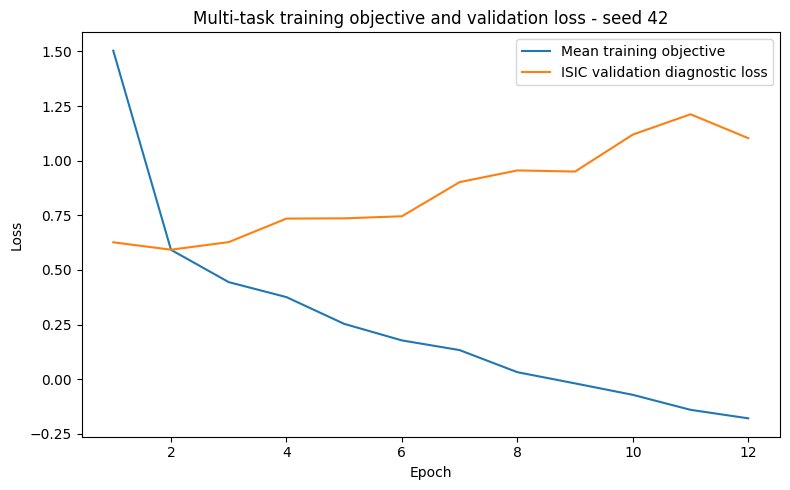

Saved: mtl_final_v2_seed_42_loss.png


In [33]:
## Plot training objective and validation loss

epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    label="Mean training objective",
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="ISIC validation diagnostic loss",
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Multi-task training objective and "
    f"validation loss - seed {TRAIN_SEED}"
)

plt.legend()
plt.tight_layout()


LOSS_FIGURE_PATH = (
    FIGURE_DIR
    / f"{RUN_NAME}_loss.png"
)

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=150,
)

plt.show()


print(
    f"Saved: "
    f"{LOSS_FIGURE_PATH.name}"
)



### 8.3 Validation balanced accuracy

ISIC validation balanced accuracy is plotted across the epochs completed during training.

Balanced accuracy gives equal importance to the three diagnostic classes and is the metric used to select the best checkpoint.

The dashed vertical line marks the epoch with the highest validation balanced accuracy.

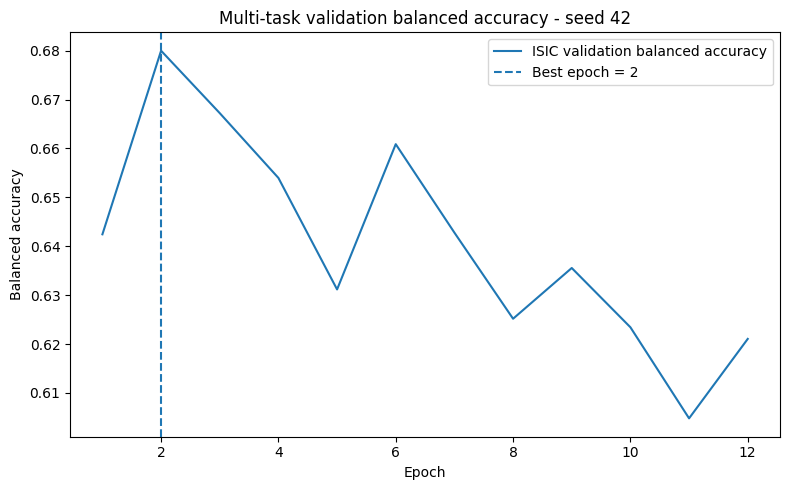

Saved: mtl_final_v2_seed_42_validation_ba.png


In [34]:
## Plot validation balanced accuracy

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history[
        "validation_balanced_accuracy"
    ],
    label="ISIC validation balanced accuracy",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}",
)

plt.xlabel("Epoch")

plt.ylabel(
    "Balanced accuracy"
)

plt.title(
    "Multi-task validation balanced accuracy "
    f"- seed {TRAIN_SEED}"
)

plt.legend()
plt.tight_layout()


VALIDATION_BA_FIGURE_PATH = (
    FIGURE_DIR
    / f"{RUN_NAME}_validation_ba.png"
)

plt.savefig(
    VALIDATION_BA_FIGURE_PATH,
    dpi=150,
)

plt.show()


print(
    f"Saved: "
    f"{VALIDATION_BA_FIGURE_PATH.name}"
)



## Section 9: Generate predictions from the selected checkpoint

The checkpoint with the highest ISIC validation balanced accuracy is reloaded after training.

The selected multi-task model is then used to generate diagnostic predictions for the ISIC validation and test partitions. For each image, the predicted class and the probabilities for Benign, Indeterminate and Malignant are retained.

The original diagnosis metadata are kept with the predictions so that the final evaluation can use both the broad three-class target and more specific diagnostic labels.

Final ROC, sensitivity-specificity, calibration and cross-dataset analyses are carried out in Notebook 05.


### 9.1 Load the selected checkpoint

The best multi-task checkpoint is reloaded before evaluation.

The checkpoint metadata are checked against the current experiment settings before its weights are used.

In [35]:
## Load the selected checkpoint

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)


if checkpoint["model_name"] != MODEL_NAME:
    raise ValueError(
        "Checkpoint model does not match MODEL_NAME."
    )

if checkpoint["training_seed"] != TRAIN_SEED:
    raise ValueError(
        "Checkpoint seed does not match TRAIN_SEED."
    )

if checkpoint["run_name"] != RUN_NAME:
    raise ValueError(
        "Checkpoint run name does not match RUN_NAME."
    )

if checkpoint["class_to_idx"] != CLASS_TO_IDX:
    raise ValueError(
        "Checkpoint class mapping does not match CLASS_TO_IDX."
    )

if checkpoint["primary_target"] != PRIMARY_TARGET:
    raise ValueError(
        "Checkpoint target does not match PRIMARY_TARGET."
    )

if checkpoint["image_size"] != IMAGE_SIZE:
    raise ValueError(
        "Checkpoint image size does not match IMAGE_SIZE."
    )

if checkpoint["aux_tasks"] != AUX_TASKS:
    raise ValueError(
        "Checkpoint auxiliary tasks do not match AUX_TASKS."
    )

if checkpoint["aux_num_classes"] != AUX_NUM_CLASSES:
    raise ValueError(
        "Checkpoint auxiliary class counts do not match."
    )

if checkpoint["aux_class_names"] != AUX_CLASS_NAMES:
    raise ValueError(
        "Checkpoint auxiliary class names do not match."
    )

if checkpoint["aux_every"] != AUX_EVERY:
    raise ValueError(
        "Checkpoint auxiliary interval does not match AUX_EVERY."
    )


best_epoch = int(
    checkpoint["epoch"]
)

best_validation_balanced_accuracy = float(
    checkpoint[
        "best_validation_balanced_accuracy"
    ]
)


model_mtl.load_state_dict(
    checkpoint["model_state_dict"]
)

eval_model = model_mtl.to(
    DEVICE
)

eval_model.eval()


print("=" * 67)
print(f"{'Selected checkpoint loaded':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"Checkpoint         : "
    f"{BEST_CHECKPOINT_PATH.name}"
)


                    Selected checkpoint loaded                     

Run name           : mtl_final_v2_seed_42
Training seed      : 42
Best epoch         : 2
Best validation BA : 0.6800
Checkpoint         : mtl_final_v2_seed_42_best.pt


### 9.2 Generate ISIC validation and test predictions

The selected checkpoint is applied to the ISIC validation and test partitions without updating the model.

For each image, the diagnostic output is converted to probabilities for Benign, Indeterminate and Malignant. Image IDs and true labels are retained for later evaluation.

Probabilities are converted to float32 before being moved to the CPU and saved.

In [36]:
## Generate diagnostic predictions

def run_inference(
    model,
    loader,
    device,
    use_amp,
):

    model.eval()

    all_ids = []
    all_labels = []
    all_predictions = []
    all_probabilities = []


    with torch.no_grad():

        for (
            images,
            labels,
            image_ids
        ) in loader:

            images = images.to(
                device,
                non_blocking=True,
            )


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):

                outputs = model(
                    images
                )

                diagnostic_outputs = (
                    outputs["diagnosis"]
                )


            probabilities = torch.softmax(
                diagnostic_outputs.float(),
                dim=1,
            )

            predictions = probabilities.argmax(
                dim=1
            )


            all_ids.extend(
                [
                    str(image_id)
                    for image_id
                    in image_ids
                ]
            )

            all_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_predictions.extend(
                predictions.cpu().numpy().tolist()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy().tolist()
            )


    return {
        "ids":
            all_ids,

        "labels":
            np.asarray(
                all_labels,
                dtype=np.int64,
            ),

        "predictions":
            np.asarray(
                all_predictions,
                dtype=np.int64,
            ),

        "probabilities":
            np.asarray(
                all_probabilities,
                dtype=np.float32,
            ),
    }


validation_outputs = run_inference(
    model=eval_model,
    loader=isic_validation_loader,
    device=DEVICE,
    use_amp=USE_AMP,
)

test_outputs = run_inference(
    model=eval_model,
    loader=isic_test_loader,
    device=DEVICE,
    use_amp=USE_AMP,
)


print("=" * 67)
print(f"{'ISIC inference complete':^67}")
print("=" * 67, "\n")

print(
    f"Validation images : "
    f"{len(validation_outputs['ids']):,}"
)

print(
    f"Test images       : "
    f"{len(test_outputs['ids']):,}"
)


                      ISIC inference complete                      

Validation images : 3,808
Test images       : 3,851



### 9.3 Verify prediction alignment

Before the prediction files are saved, the collected image IDs and labels are checked against the fixed ISIC validation and test partitions.

The diagnostic probability arrays are also checked for the expected three-class shape, finite values and rows that sum to one.

In [37]:
## Verify prediction alignment

def verify_predictions(
    dataframe,
    outputs,
    split_name,
):

    expected_ids = (
        dataframe["isic_id"]
        .astype(str)
        .tolist()
    )

    expected_labels = (
        dataframe[PRIMARY_TARGET]
        .map(CLASS_TO_IDX)
        .to_numpy()
    )


    if outputs["ids"] != expected_ids:
        raise ValueError(
            f"{split_name}: prediction IDs "
            "do not match the fixed split."
        )


    if not np.array_equal(
        outputs["labels"],
        expected_labels,
    ):
        raise ValueError(
            f"{split_name}: prediction labels "
            "do not match the fixed split."
        )


    expected_shape = (
        len(dataframe),
        NUM_CLASSES,
    )

    if (
        outputs["probabilities"].shape
        != expected_shape
    ):
        raise ValueError(
            f"{split_name}: probability shape "
            "is incorrect."
        )


    if not np.isfinite(
        outputs["probabilities"]
    ).all():

        raise ValueError(
            f"{split_name}: non-finite "
            "probabilities found."
        )


    if not np.allclose(
        outputs["probabilities"].sum(axis=1),
        1.0,
        atol=1e-5,
    ):

        raise ValueError(
            f"{split_name}: probabilities "
            "do not sum to one."
        )


    print(
        f"{split_name:10s}: "
        f"{len(expected_ids):,} predictions verified"
    )


print("=" * 67)
print(f"{'Prediction checks':^67}")
print("=" * 67, "\n")


verify_predictions(
    isic_validation_df,
    validation_outputs,
    "Validation",
)

verify_predictions(
    isic_test_df,
    test_outputs,
    "Test",
)

                         Prediction checks                         

Validation: 3,808 predictions verified
Test      : 3,851 predictions verified


### 9.4 Save validation and test predictions

The ISIC validation and test predictions are saved as separate CSV files.

Each row retains the image ID, the three diagnosis fields, the true and predicted three-class labels, and the predicted probability for each class.

`diagnosis_2` and `diagnosis_3` are retained as metadata rather than model targets. They provide the more detailed diagnostic information needed for later melanoma-focused evaluation.

The saved class probabilities allow Notebook 05 to perform the final diagnostic evaluation without rerunning the model.

In [38]:



## Save validation and test predictions

def build_prediction_table(
    dataframe,
    outputs,
    split_name,
):

    return pd.DataFrame({
        "isic_id":
            outputs["ids"],

        "diagnosis_1":
            dataframe["diagnosis_1"].values,

        "diagnosis_2":
            dataframe["diagnosis_2"].values,

        "diagnosis_3":
            dataframe["diagnosis_3"].values,

        "true_label":
            outputs["labels"],

        "true_class":
            [
                IDX_TO_CLASS[label]
                for label
                in outputs["labels"]
            ],

        "predicted_label":
            outputs["predictions"],

        "predicted_class":
            [
                IDX_TO_CLASS[label]
                for label
                in outputs["predictions"]
            ],

        "P_Benign":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Benign"]
            ],

        "P_Indeterminate":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Indeterminate"]
            ],

        "P_Malignant":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Malignant"]
            ],

        "training_seed":
            TRAIN_SEED,

        "run_name":
            RUN_NAME,

        "split":
            split_name,
    })


validation_predictions_df = (
    build_prediction_table(
        isic_validation_df,
        validation_outputs,
        "validation",
    )
)

test_predictions_df = (
    build_prediction_table(
        isic_test_df,
        test_outputs,
        "test",
    )
)


VALIDATION_PREDICTIONS_PATH = (
    PREDICTION_DIR
    / f"{RUN_NAME}_validation_predictions.csv"
)

TEST_PREDICTIONS_PATH = (
    PREDICTION_DIR
    / f"{RUN_NAME}_test_predictions.csv"
)


validation_predictions_df.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

test_predictions_df.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Prediction files saved':^67}")
print("=" * 67, "\n")

print(
    f"Validation : "
    f"{VALIDATION_PREDICTIONS_PATH.name}"
)

print(
    f"Test       : "
    f"{TEST_PREDICTIONS_PATH.name}"
)


                      Prediction files saved                       

Validation : mtl_final_v2_seed_42_validation_predictions.csv
Test       : mtl_final_v2_seed_42_test_predictions.csv


### 9.5 Run-level check

Balanced accuracy is recalculated from the ISIC predictions produced by the selected checkpoint.

The validation value should reproduce the balanced accuracy stored with the checkpoint. Test balanced accuracy is reported as a check for this individual multi-task run.

The final comparison across the three training seeds is carried out in Notebook 05.

In [39]:
## Run-level balanced accuracy

validation_balanced_accuracy_check = (
    balanced_accuracy_score(
        validation_outputs["labels"],
        validation_outputs["predictions"],
    )
)

test_balanced_accuracy_check = (
    balanced_accuracy_score(
        test_outputs["labels"],
        test_outputs["predictions"],
    )
)


if not np.isclose(
    validation_balanced_accuracy_check,
    best_validation_balanced_accuracy,
):
    raise ValueError(
        "Reloaded validation balanced accuracy "
        "does not match the saved checkpoint."
    )


print("=" * 67)
print(f"{'Run-level results':^67}")
print("=" * 67, "\n")

print(
    f"Validation BA : "
    f"{validation_balanced_accuracy_check:.4f}"
)

print(
    f"Test BA       : "
    f"{test_balanced_accuracy_check:.4f}"
)

                         Run-level results                         

Validation BA : 0.6800
Test BA       : 0.7214


## Section 10: Evaluate the Derm7pt auxiliary tasks

The selected multi-task checkpoint is evaluated on the Derm7pt validation and test partitions.

Predictions are generated separately for each of the seven auxiliary tasks.

Balanced accuracy is reported separately for each task because the auxiliary class distributions are imbalanced.

During training, the Derm7pt validation partition was used only to monitor auxiliary validation loss for signs of overfitting.

Derm7pt validation loss did not affect optimisation, checkpoint selection, early stopping, the learning-rate scheduler or the fixed 1:4 training schedule.

The Derm7pt test partition remained unused until evaluation of the selected checkpoint.

### 10.1 Generate auxiliary predictions

The selected checkpoint is applied to the Derm7pt validation and test partitions without updating the model.

For each auxiliary task, logits are converted to class probabilities and the highest-probability class is retained as the prediction.

In [40]:

## Generate Derm7pt auxiliary predictions

def run_auxiliary_inference(
    model,
    loader,
    device,
    use_amp,
):

    model.eval()

    collected = {
        task_name: {
            "labels": [],
            "predictions": [],
            "probabilities": [],
        }
        for task_name in AUX_TASKS
    }


    with torch.no_grad():

        for (
            images,
            targets
        ) in loader:

            images = images.to(
                device,
                non_blocking=True,
            )


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):

                outputs = model(
                    images
                )


            for task_name in AUX_TASKS:

                probabilities = torch.softmax(
                    outputs[
                        task_name
                    ].float(),
                    dim=1,
                )

                predictions = probabilities.argmax(
                    dim=1
                )


                collected[
                    task_name
                ][
                    "labels"
                ].extend(
                    targets[
                        task_name
                    ]
                    .cpu()
                    .numpy()
                    .tolist()
                )

                collected[
                    task_name
                ][
                    "predictions"
                ].extend(
                    predictions
                    .cpu()
                    .numpy()
                    .tolist()
                )

                collected[
                    task_name
                ][
                    "probabilities"
                ].extend(
                    probabilities
                    .cpu()
                    .numpy()
                    .tolist()
                )


    return {
        task_name: {
            "labels":
                np.asarray(
                    collected[
                        task_name
                    ][
                        "labels"
                    ],
                    dtype=np.int64,
                ),

            "predictions":
                np.asarray(
                    collected[
                        task_name
                    ][
                        "predictions"
                    ],
                    dtype=np.int64,
                ),

            "probabilities":
                np.asarray(
                    collected[
                        task_name
                    ][
                        "probabilities"
                    ],
                    dtype=np.float32,
                ),
        }
        for task_name in AUX_TASKS
    }


derm7pt_validation_outputs = (
    run_auxiliary_inference(
        model=eval_model,
        loader=derm7pt_validation_loader,
        device=DEVICE,
        use_amp=USE_AMP,
    )
)

derm7pt_test_outputs = (
    run_auxiliary_inference(
        model=eval_model,
        loader=derm7pt_test_loader,
        device=DEVICE,
        use_amp=USE_AMP,
    )
)


print("=" * 67)
print(f"{'Derm7pt inference complete':^67}")
print("=" * 67, "\n")

print(
    f"Validation images : "
    f"{len(derm7pt_validation_df)}"
)

print(
    f"Test images       : "
    f"{len(derm7pt_test_df)}"
)


                    Derm7pt inference complete                     

Validation images : 203
Test images       : 395


### 10.2 Verify auxiliary predictions

The collected labels are checked against the saved Derm7pt targets.

For every auxiliary task, the probability array is also checked for the expected shape, finite values and rows that sum to one.

In [41]:
## Verify Derm7pt auxiliary predictions

def verify_auxiliary_outputs(
    targets_df,
    outputs,
    split_name,
):

    for task_name in AUX_TASKS:

        expected_labels = (
            targets_df[
                task_name
            ]
            .to_numpy(
                dtype=np.int64
            )
        )

        actual_labels = (
            outputs[
                task_name
            ][
                "labels"
            ]
        )

        predictions = (
            outputs[
                task_name
            ][
                "predictions"
            ]
        )

        probabilities = (
            outputs[
                task_name
            ][
                "probabilities"
            ]
        )


        if not np.array_equal(
            actual_labels,
            expected_labels,
        ):
            raise ValueError(
                f"{split_name} / {task_name}: "
                "labels do not match the "
                "saved Derm7pt targets."
            )


        expected_shape = (
            len(targets_df),
            AUX_NUM_CLASSES[
                task_name
            ],
        )

        if (
            probabilities.shape
            != expected_shape
        ):
            raise ValueError(
                f"{split_name} / {task_name}: "
                "probability shape is incorrect."
            )


        if predictions.shape != (
            len(targets_df),
        ):
            raise ValueError(
                f"{split_name} / {task_name}: "
                "prediction shape is incorrect."
            )


        if not np.isfinite(
            probabilities
        ).all():
            raise ValueError(
                f"{split_name} / {task_name}: "
                "non-finite probabilities found."
            )


        if not np.allclose(
            probabilities.sum(
                axis=1
            ),
            1.0,
            atol=1e-5,
        ):
            raise ValueError(
                f"{split_name} / {task_name}: "
                "probabilities do not sum to one."
            )


        if not np.array_equal(
            predictions,
            probabilities.argmax(
                axis=1
            ),
        ):
            raise ValueError(
                f"{split_name} / {task_name}: "
                "predictions do not match "
                "the probability argmax."
            )


    print(
        f"{split_name:10s}: "
        f"{len(targets_df)} images verified"
    )


print("=" * 67)
print(f"{'Derm7pt prediction checks':^67}")
print("=" * 67, "\n")


verify_auxiliary_outputs(
    derm7pt_validation_targets,
    derm7pt_validation_outputs,
    "Validation",
)

verify_auxiliary_outputs(
    derm7pt_test_targets,
    derm7pt_test_outputs,
    "Test",
)


                     Derm7pt prediction checks                     

Validation: 203 images verified
Test      : 395 images verified


### 10.3 Calculate auxiliary balanced accuracy

Balanced accuracy is calculated separately for each of the seven auxiliary tasks on the Derm7pt validation and test partitions.

In [42]:



## Calculate auxiliary balanced accuracy

def calculate_auxiliary_metrics(
    outputs
):

    metrics = {}

    for task_name in AUX_TASKS:

        labels = (
            outputs[
                task_name
            ][
                "labels"
            ]
        )

        predictions = (
            outputs[
                task_name
            ][
                "predictions"
            ]
        )


        metrics[
            task_name
        ] = {
            "balanced_accuracy":
                float(
                    balanced_accuracy_score(
                        labels,
                        predictions,
                    )
                ),

            "n":
                int(
                    len(labels)
                ),
        }


    return metrics


derm7pt_validation_metrics = (
    calculate_auxiliary_metrics(
        derm7pt_validation_outputs
    )
)

derm7pt_test_metrics = (
    calculate_auxiliary_metrics(
        derm7pt_test_outputs
    )
)


print("=" * 67)
print(f"{'Derm7pt auxiliary results':^67}")
print("=" * 67, "\n")


for task_name in AUX_TASKS:

    validation_ba = (
        derm7pt_validation_metrics[
            task_name
        ][
            "balanced_accuracy"
        ]
    )

    test_ba = (
        derm7pt_test_metrics[
            task_name
        ][
            "balanced_accuracy"
        ]
    )

    print(
        f"{task_name:20s} | "
        f"Val BA: {validation_ba:.4f} | "
        f"Test BA: {test_ba:.4f}"
    )


                     Derm7pt auxiliary results                     

pigment_network      | Val BA: 0.6223 | Test BA: 0.6652
blue_whitish_veil    | Val BA: 0.8703 | Test BA: 0.8143
vascular_structures  | Val BA: 0.5658 | Test BA: 0.5325
pigmentation         | Val BA: 0.6511 | Test BA: 0.5904
streaks              | Val BA: 0.6803 | Test BA: 0.6003
dots_and_globules    | Val BA: 0.5553 | Test BA: 0.5571
regression_structures | Val BA: 0.6467 | Test BA: 0.7030


### 10.4 Save auxiliary predictions and metrics

The Derm7pt validation and test predictions are saved separately.

Each prediction table retains the Derm7pt metadata index, dermoscopic image filename, true and predicted class for every auxiliary task, and the corresponding class probabilities.

A JSON file stores the per-task balanced accuracy values for this run.

In [43]:
## Build and save Derm7pt auxiliary prediction tables

def build_auxiliary_prediction_table(
    dataframe,
    outputs,
    split_name,
):

    prediction_df = pd.DataFrame({
        "metadata_index":
            dataframe.index.to_numpy(),

        "derm":
            dataframe[
                "derm"
            ]
            .astype(str)
            .to_numpy(),
    })


    for task_name in AUX_TASKS:

        labels = (
            outputs[
                task_name
            ][
                "labels"
            ]
        )

        predictions = (
            outputs[
                task_name
            ][
                "predictions"
            ]
        )

        probabilities = (
            outputs[
                task_name
            ][
                "probabilities"
            ]
        )


        prediction_df[
            f"{task_name}_true_label"
        ] = labels

        prediction_df[
            f"{task_name}_true_class"
        ] = [
            AUX_CLASS_NAMES[
                task_name
            ][label]
            for label in labels
        ]

        prediction_df[
            f"{task_name}_predicted_label"
        ] = predictions

        prediction_df[
            f"{task_name}_predicted_class"
        ] = [
            AUX_CLASS_NAMES[
                task_name
            ][prediction]
            for prediction in predictions
        ]


        for (
            class_index,
            class_name
        ) in enumerate(
            AUX_CLASS_NAMES[
                task_name
            ]
        ):

            prediction_df[
                f"{task_name}_P_{class_name}"
            ] = probabilities[
                :,
                class_index
            ]


    prediction_df[
        "training_seed"
    ] = TRAIN_SEED

    prediction_df[
        "run_name"
    ] = RUN_NAME

    prediction_df[
        "split"
    ] = split_name


    return prediction_df


derm7pt_validation_predictions_df = (
    build_auxiliary_prediction_table(
        derm7pt_validation_df,
        derm7pt_validation_outputs,
        "validation",
    )
)

derm7pt_test_predictions_df = (
    build_auxiliary_prediction_table(
        derm7pt_test_df,
        derm7pt_test_outputs,
        "test",
    )
)


DERM7PT_VALIDATION_PREDICTIONS_PATH = (
    AUXILIARY_DIR
    / (
        f"{RUN_NAME}_derm7pt_"
        "validation_auxiliary_predictions.csv"
    )
)

DERM7PT_TEST_PREDICTIONS_PATH = (
    AUXILIARY_DIR
    / (
        f"{RUN_NAME}_derm7pt_"
        "test_auxiliary_predictions.csv"
    )
)

DERM7PT_AUXILIARY_METRICS_PATH = (
    AUXILIARY_DIR
    / (
        f"{RUN_NAME}_derm7pt_"
        "auxiliary_metrics.json"
    )
)


derm7pt_validation_predictions_df.to_csv(
    DERM7PT_VALIDATION_PREDICTIONS_PATH,
    index=False,
)

derm7pt_test_predictions_df.to_csv(
    DERM7PT_TEST_PREDICTIONS_PATH,
    index=False,
)


derm7pt_auxiliary_summary = {
    "run_name":
        RUN_NAME,

    "training_seed":
        int(TRAIN_SEED),

    "checkpoint_file":
        str(BEST_CHECKPOINT_PATH),

    "checkpoint_selection":
        "ISIC validation balanced accuracy",

    "best_epoch":
        int(best_epoch),

    "aux_class_names":
        AUX_CLASS_NAMES,

    "validation":
        derm7pt_validation_metrics,

    "test":
        derm7pt_test_metrics,
}


with open(
    DERM7PT_AUXILIARY_METRICS_PATH,
    "w"
) as file:

    json.dump(
        derm7pt_auxiliary_summary,
        file,
        indent=2,
    )


print("=" * 67)
print(f"{'Derm7pt auxiliary outputs saved':^67}")
print("=" * 67, "\n")

print(
    f"Validation predictions : "
    f"{DERM7PT_VALIDATION_PREDICTIONS_PATH.name}"
)

print(
    f"Test predictions       : "
    f"{DERM7PT_TEST_PREDICTIONS_PATH.name}"
)

print(
    f"Metrics                : "
    f"{DERM7PT_AUXILIARY_METRICS_PATH.name}"
)


                  Derm7pt auxiliary outputs saved                  

Validation predictions : mtl_final_v2_seed_42_derm7pt_validation_auxiliary_predictions.csv
Test predictions       : mtl_final_v2_seed_42_derm7pt_test_auxiliary_predictions.csv
Metrics                : mtl_final_v2_seed_42_derm7pt_auxiliary_metrics.json


## Section 11: Save the multi-task run

The selected checkpoint, training history, ISIC diagnostic predictions and Derm7pt auxiliary outputs form the record for this multi-task seed.

A CSV version of the epoch-by-epoch training history is saved for inspection. A compact JSON summary records the main experiment settings, selected checkpoint information, run-level results and output-file locations.

Final diagnostic, screening, calibration and cross-dataset analyses are carried out later in Notebook 05.

### 11.1 Save the training history

The epoch-by-epoch training history is saved as a CSV file.

This includes the multi-task training objective, ISIC validation loss, ISIC validation balanced accuracy, the number of Derm7pt auxiliary training batches, the overall Derm7pt auxiliary validation loss, the validation loss for each auxiliary task and the time taken for each completed epoch.

In [44]:
## Save the training history


HISTORY_CSV_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_training_history.csv"
)


history_df = pd.DataFrame({
    "epoch":
        np.arange(
            1,
            len(history["train_loss"]) + 1,
        ),

    "train_loss":
        history["train_loss"],

    "validation_loss":
        history["validation_loss"],

    "validation_balanced_accuracy":
        history[
            "validation_balanced_accuracy"
        ],

    "auxiliary_batches":
        history[
            "auxiliary_batches"
        ],

    "derm7pt_validation_auxiliary_loss":
        history[
            "derm7pt_validation_auxiliary_loss"
        ],

    "epoch_time_seconds":
        history[
            "epoch_time_seconds"
        ],
})


for task_name in AUX_TASKS:

    history_df[
        f"derm7pt_validation_loss_{task_name}"
    ] = [
        epoch_losses[task_name]
        for epoch_losses
        in history[
            "derm7pt_validation_auxiliary_loss_by_task"
        ]
    ]


history_df.to_csv(
    HISTORY_CSV_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Training history saved':^67}")
print("=" * 67, "\n")

print(
    f"Rows : {len(history_df)}"
)

print(
    f"File : {HISTORY_CSV_PATH.name}"
)

                      Training history saved                       

Rows : 12
File : mtl_final_v2_seed_42_training_history.csv


### 11.2 Save the run summary

A compact JSON file is saved with the main multi-task training settings, selected checkpoint information, run-level ISIC balanced accuracy values and the locations of the files produced by this run.

The Derm7pt auxiliary output files are also recorded. Final ROC, sensitivity-specificity, melanoma, calibration and cross-dataset analyses are calculated later in Notebook 05.

In [45]:
## Save the multi-task run summary


SUMMARY_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_summary.json"
)


run_summary = {
    "experiment":
        "multi_task_swin",

    "run_name":
        RUN_NAME,

    "model_name":
        MODEL_NAME,

    "training_seed":
        int(TRAIN_SEED),

    "image_size":
        int(IMAGE_SIZE),

    "batch_size":
        int(BATCH_SIZE),

    "learning_rate":
        float(LEARNING_RATE),

    "weight_decay":
        float(WEIGHT_DECAY),

    "maximum_epochs":
        int(MAX_EPOCHS),

    "early_stopping_patience":
        int(
            EARLY_STOPPING_PATIENCE
        ),

    "aux_every":
        int(AUX_EVERY),

    "completed_epochs":
        int(completed_epochs),

    "stopped_early":
        bool(stopped_early),

    "checkpoint_selection":
        "ISIC validation balanced accuracy",

    "best_epoch":
        int(best_epoch),

    "best_validation_balanced_accuracy":
        float(
            best_validation_balanced_accuracy
        ),

    "reloaded_validation_balanced_accuracy":
        float(
            validation_balanced_accuracy_check
        ),

    "test_balanced_accuracy_run_level":
        float(
            test_balanced_accuracy_check
        ),

    "primary_target":
        PRIMARY_TARGET,

    "class_to_idx": {
        key: int(value)
        for key, value
        in CLASS_TO_IDX.items()
    },

    "diagnostic_class_weighting_method":
        DIAGNOSTIC_CLASS_WEIGHTING_METHOD,

    "diagnostic_class_counts": {
        class_name:
            int(
                isic_class_counts.loc[
                    class_name
                ]
            )
        for class_name
        in CLASS_NAMES
    },

    "diagnostic_raw_inverse_frequency_weights": {
        class_name:
            float(
                raw_diagnostic_class_weights.loc[
                    class_name
                ]
            )
        for class_name
        in CLASS_NAMES
    },

    "diagnostic_class_weights": {
        class_name:
            float(
                diagnostic_class_weights.loc[
                    class_name
                ]
            )
        for class_name
        in CLASS_NAMES
    },

    "auxiliary_class_weighting_method":
        AUXILIARY_CLASS_WEIGHTING_METHOD,

    "aux_tasks":
        AUX_TASKS,

    "aux_num_classes": {
        task_name:
            int(
                AUX_NUM_CLASSES[
                    task_name
                ]
            )
        for task_name
        in AUX_TASKS
    },

    "aux_class_names":
        AUX_CLASS_NAMES,

    "auxiliary_class_weights": {
        task_name: {
            class_name:
                float(
                    aux_class_weights[
                        task_name
                    ].iloc[
                        class_index
                    ]
                )
            for (
                class_index,
                class_name
            ) in enumerate(
                AUX_CLASS_NAMES[
                    task_name
                ]
            )
        }
        for task_name in AUX_TASKS
    },

    "derm7pt_validation_monitoring": (
        "Per-head class-weighted validation loss "
        "recorded once per epoch for monitoring only. "
        "It does not affect optimisation, checkpoint "
        "selection, early stopping, the learning-rate "
        "scheduler or the fixed 1:4 batch schedule."
    ),

    "log_variances": {
        task_name:
            float(
                checkpoint[
                    "log_variances"
                ][
                    task_name
                ]
            )
        for task_name in ALL_TASKS
    },

    "checkpoint_file":
        str(
            BEST_CHECKPOINT_PATH
        ),

    "history_json_file":
        str(
            HISTORY_JSON_PATH
        ),

    "history_csv_file":
        str(
            HISTORY_CSV_PATH
        ),

    "validation_predictions_file":
        str(
            VALIDATION_PREDICTIONS_PATH
        ),

    "test_predictions_file":
        str(
            TEST_PREDICTIONS_PATH
        ),

    "derm7pt_validation_predictions_file":
        str(
            DERM7PT_VALIDATION_PREDICTIONS_PATH
        ),

    "derm7pt_test_predictions_file":
        str(
            DERM7PT_TEST_PREDICTIONS_PATH
        ),

    "derm7pt_auxiliary_metrics_file":
        str(
            DERM7PT_AUXILIARY_METRICS_PATH
        ),

    "loss_figure_file":
        str(
            LOSS_FIGURE_PATH
        ),

    "validation_ba_figure_file":
        str(
            VALIDATION_BA_FIGURE_PATH
        ),
}


with open(
    SUMMARY_PATH,
    "w"
) as file:

    json.dump(
        run_summary,
        file,
        indent=2,
    )


print("=" * 67)
print(f"{'Multi-task run summary saved':^67}")
print("=" * 67, "\n")

print(
    f"File : {SUMMARY_PATH.name}"
)

                   Multi-task run summary saved                    

File : mtl_final_v2_seed_42_summary.json


### 11.3 Final integrity check

The main files produced by the multi-task run are checked before the run is treated as complete.

The ISIC diagnostic prediction tables and Derm7pt auxiliary prediction tables are checked against their corresponding fixed data partitions. The saved training history is also checked against the number of completed epochs.

In [46]:
## Check the saved multi-task outputs

files_to_check = {
    "best checkpoint":
        BEST_CHECKPOINT_PATH,

    "history JSON":
        HISTORY_JSON_PATH,

    "history CSV":
        HISTORY_CSV_PATH,

    "loss figure":
        LOSS_FIGURE_PATH,

    "validation BA figure":
        VALIDATION_BA_FIGURE_PATH,

    "ISIC validation predictions":
        VALIDATION_PREDICTIONS_PATH,

    "ISIC test predictions":
        TEST_PREDICTIONS_PATH,

    "Derm7pt validation predictions":
        DERM7PT_VALIDATION_PREDICTIONS_PATH,

    "Derm7pt test predictions":
        DERM7PT_TEST_PREDICTIONS_PATH,

    "Derm7pt auxiliary metrics":
        DERM7PT_AUXILIARY_METRICS_PATH,

    "run summary":
        SUMMARY_PATH,
}


print("=" * 67)
print(f"{'Multi-task output check':^67}")
print("=" * 67, "\n")


for name, path in files_to_check.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Missing {name}: {path}"
        )

    print(
        f"{name:31s}: OK"
    )


if (
    len(validation_predictions_df)
    != len(isic_validation_df)
):
    raise ValueError(
        "ISIC validation prediction row count "
        "does not match isic_validation_df."
    )


if (
    len(test_predictions_df)
    != len(isic_test_df)
):
    raise ValueError(
        "ISIC test prediction row count "
        "does not match isic_test_df."
    )


if (
    len(derm7pt_validation_predictions_df)
    != len(derm7pt_validation_df)
):
    raise ValueError(
        "Derm7pt validation prediction row count "
        "does not match derm7pt_validation_df."
    )


if (
    len(derm7pt_test_predictions_df)
    != len(derm7pt_test_df)
):
    raise ValueError(
        "Derm7pt test prediction row count "
        "does not match derm7pt_test_df."
    )


if len(history_df) != completed_epochs:
    raise ValueError(
        "Training history row count does not "
        "match completed_epochs."
    )


if set(
    derm7pt_validation_metrics.keys()
) != set(AUX_TASKS):
    raise ValueError(
        "Derm7pt validation metrics do not "
        "contain all auxiliary tasks."
    )


if set(
    derm7pt_test_metrics.keys()
) != set(AUX_TASKS):
    raise ValueError(
        "Derm7pt test metrics do not "
        "contain all auxiliary tasks."
    )


print(
    "\nAll required multi-task files are present "
    "and output counts match."
)

                      Multi-task output check                      

best checkpoint                : OK
history JSON                   : OK
history CSV                    : OK
loss figure                    : OK
validation BA figure           : OK
ISIC validation predictions    : OK
ISIC test predictions          : OK
Derm7pt validation predictions : OK
Derm7pt test predictions       : OK
Derm7pt auxiliary metrics      : OK
run summary                    : OK

All required multi-task files are present and output counts match.


### 11.4 Multi-task run summary

The final cell prints the main information for this individual multi-task run.

The final comparison across the three training seeds and the main diagnostic analyses are carried out later in Notebook 05.


In [47]:
## Final multi-task run summary

print("=" * 67)
print(f"{'Multi-task run complete':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Completed epochs   : {completed_epochs}")
print(f"Stopped early      : {stopped_early}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"ISIC test BA       : "
    f"{test_balanced_accuracy_check:.4f}"
)


print("\nDerm7pt test balanced accuracy")

for task_name in AUX_TASKS:

    test_ba = (
        derm7pt_test_metrics[
            task_name
        ][
            "balanced_accuracy"
        ]
    )

    print(
        f"{task_name:20s}: "
        f"{test_ba:.4f}"
    )


print(
    f"\nCheckpoint         : "
    f"{BEST_CHECKPOINT_PATH.name}"
)

print(
    f"Summary file       : "
    f"{SUMMARY_PATH.name}"
)

                      Multi-task run complete                      

Run name           : mtl_final_v2_seed_42
Training seed      : 42
Completed epochs   : 12
Stopped early      : True
Best epoch         : 2
Best validation BA : 0.6800
ISIC test BA       : 0.7214

Derm7pt test balanced accuracy
pigment_network     : 0.6652
blue_whitish_veil   : 0.8143
vascular_structures : 0.5325
pigmentation        : 0.5904
streaks             : 0.6003
dots_and_globules   : 0.5571
regression_structures: 0.7030

Checkpoint         : mtl_final_v2_seed_42_best.pt
Summary file       : mtl_final_v2_seed_42_summary.json
